In [17]:
from utils import *
from concurrent.futures import ProcessPoolExecutor
import concurrent
%matplotlib inline

In [18]:
EJ = 3
EC = 0.6
EL = 0.13
Er = 7.2622522
g_strength = 0.3

qubit_level = 30
osc_level = 40


qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=110,truncated_dim=qubit_level)
osc = scqubits.Oscillator(E_osc=Er,truncated_dim=osc_level)
hilbertspace = scqubits.HilbertSpace([qbt, osc])
hilbertspace.add_interaction(g_strength=g_strength,op1=qbt.n_operator,op2=osc.creation_operator,add_hc=True)
hilbertspace.generate_lookup()
product_to_dressed = generate_single_mapping(hilbertspace.hamiltonian())
energies=  hilbertspace.eigenvals(qubit_level*osc_level)


In [19]:
products_to_keep = []

for ql in range(15):
    for ol in range(40):
        products_to_keep.append([ql,ol])


def truncate_function(qobj):
    return truncate_custom(qobj, products_to_keep, product_to_dressed)


a = hilbertspace.op_in_dressed_eigenbasis(op=osc.annihilation_operator)
a = qutip.Qobj(a[:, :])
a_trunc = truncate_function(a)

(evals,) = hilbertspace["evals"]
diag_dressed_hamiltonian = (
        2 * np.pi * qutip.Qobj(np.diag(evals),
        dims=[hilbertspace.subsystem_dims] * 2)
)
diag_dressed_hamiltonian = qutip.Qobj(diag_dressed_hamiltonian[:, :])
diag_dressed_hamiltonian = truncate_function(diag_dressed_hamiltonian)

w_d = transition_frequency(hilbertspace,product_to_dressed[(0,0)],product_to_dressed[(0,1)] ) 


t_stop = 478
tot_time =900
tlist = np.linspace(0, tot_time, tot_time)

amp = 0.004


In [20]:
from functions import write_mesolve
write_mesolve(w_d,amp,product_to_dressed,products_to_keep,t_stop=t_stop)

In [21]:

from temp_functions import mesolve_and_pad, square_cos
H_with_drive = [
    diag_dressed_hamiltonian,
    [a_trunc+a_trunc.dag(), square_cos],
]

results = [None] * 4
with ProcessPoolExecutor(max_workers=4) as executor:
    futures = {executor.submit(mesolve_and_pad, 
                               rho0=truncate_function(qutip.basis(hilbertspace.dimension, product_to_dressed[(i, 0)])), 
                               H_with_drive=H_with_drive,
                               tlist=tlist, 
                               full_dim=hilbertspace.dimension,
                               ): i for i in range(4)}
    
    for future in concurrent.futures.as_completed(futures):
        original_index = futures[future]
        results[original_index] = future.result()


import pickle
with open('pickles/sesolve_detection_results_verify_qubit_transi.pkl', 'wb') as file:
    pickle.dump(results, file)


 Total run time: 2530.87s] Elapsed 2530.87s / Remaining 00:00:00:00
 Total run time: 2833.99s] Elapsed 2833.99s / Remaining 00:00:00:00
 Total run time: 2934.00s] Elapsed 2934.00s / Remaining 00:00:00:00
 Total run time: 2939.74s] Elapsed 2939.74s / Remaining 00:00:00:00


In [12]:
with open('pickles/sesolve_detection_results_verify_qubit_transi.pkl', 'rb') as file:
    results = pickle.load(file)

In [22]:
tlist[-1]

900.0

In [23]:


lists = []
for ql in [0,1,2]:
    pop_list = []
    for t_idx in tqdm(range(len(tlist)), desc = "t loop"):
        dm = results[ql].states[t_idx]
        pop_sum = 0
        for q in range(qubit_level):
            if q != ql:
                for o in range(osc_level):
                    product_state = (q, o)
                    dressed_state = product_to_dressed[product_state]
                    basis_state = qutip.basis(dm.dims[0][0], dressed_state)
                    expectation_value = qutip.expect(basis_state * basis_state.dag(), dm)
                    pop_sum += expectation_value

        pop_list.append(pop_sum)
    print(pop_list)
    lists.append(pop_list)


t loop:   0%|          | 0/900 [00:00<?, ?it/s]

[0.0, 1.7045819382468562e-06, 4.692392446829153e-06, 5.611287411415921e-06, 2.4554923265897615e-06, 3.236871235300996e-06, 3.7508096578882266e-06, 6.565725241173992e-06, 4.178829752442661e-06, 3.7218641264211164e-06, 2.4959970630334857e-06, 5.936392412613576e-06, 5.320885812200958e-06, 5.221791127067402e-06, 2.2420737000257854e-06, 4.525786822845295e-06, 5.052703649555492e-06, 6.631272490944642e-06, 3.333028376409391e-06, 3.7120423756874425e-06, 3.694826493212745e-06, 6.841975051794702e-06, 4.891256413679918e-06, 4.302843763936356e-06, 2.4763631516124476e-06, 5.72085727230613e-06, 5.5888514549146815e-06, 5.840878554506261e-06, 2.4984021972139706e-06, 4.281675743139553e-06, 4.835213185746818e-06, 7.004255304623132e-06, 3.7861722397310314e-06, 3.806414037223398e-06, 3.304152205509245e-06, 6.774112061737019e-06, 5.223129883677226e-06, 4.727742344989655e-06, 2.3606218032301358e-06, 5.361871962657995e-06, 5.544671429433277e-06, 6.2555784446336146e-06, 2.8558173069525077e-06, 4.0420437659747

t loop:   0%|          | 0/900 [00:00<?, ?it/s]

[0.0, 1.590627912302839e-06, 5.666962930591547e-06, 1.166345735928124e-05, 1.8005305584811786e-05, 2.022538318002683e-05, 2.319145026487631e-05, 2.064289581672927e-05, 1.8801715650230504e-05, 1.2595762102321263e-05, 9.202788225027157e-06, 4.017781886207679e-06, 3.840301550209825e-06, 3.354725467931067e-06, 7.970065314437637e-06, 1.1290292663758061e-05, 1.7526957350924994e-05, 2.0073492064001774e-05, 2.3136504107884952e-05, 2.1118012354150963e-05, 1.929641919775327e-05, 1.3414472279614983e-05, 7.510405869580618e-06, 4.833220267036397e-06, 1.8796346984229069e-06, 3.7036521408975477e-06, 5.632619182209428e-06, 1.1350461616472511e-05, 1.5262302270906375e-05, 2.0420618495417196e-05, 2.1463979357569394e-05, 2.2139128085015328e-05, 1.82692543392871e-05, 1.4953139251595546e-05, 8.918969770187886e-06, 6.065706233865976e-06, 2.685771568705841e-06, 4.33802450272751e-06, 5.72863264403429e-06, 1.154896330988914e-05, 1.5024756684944153e-05, 2.0650411100985485e-05, 2.1393678454312103e-05, 2.050059651

t loop:   0%|          | 0/900 [00:00<?, ?it/s]

[0.0, 2.9092909687117156e-07, 6.062011126896121e-07, 4.840030966842034e-07, 3.644293116831209e-07, 8.266282084226705e-07, 1.8419434386094564e-06, 3.2411619721282773e-06, 2.297948257994764e-06, 4.201387866959428e-06, 2.5148428295386302e-06, 3.878980480216134e-06, 2.483011472575587e-06, 4.234773322292194e-06, 2.608093545072974e-06, 4.547587159878741e-06, 3.081357726033158e-06, 4.465222976080071e-06, 2.4927991879016155e-06, 4.500903990141723e-06, 3.0552218226654466e-06, 4.728098135230392e-06, 2.993553002612669e-06, 4.822159225367594e-06, 2.8106592980384223e-06, 4.4044099106017105e-06, 3.005448620351412e-06, 5.085816927215417e-06, 3.0920296477041316e-06, 4.65281526704e-06, 2.9547856228364423e-06, 4.6902308147297195e-06, 2.854699233679349e-06, 4.94076849301589e-06, 3.3627207041969798e-06, 4.800297691903095e-06, 2.728438420751268e-06, 4.717049259394041e-06, 3.1051141954507618e-06, 4.843521218869936e-06, 3.1578590132070802e-06, 5.022151401232642e-06, 2.9067790555270635e-06, 4.49405210754294e-

Text(0.5, 0, 't (ns)')

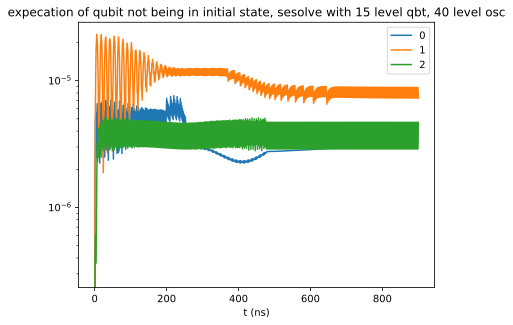

In [33]:
for ql,pop_list in enumerate(lists): 
    plt.plot(tlist,pop_list,label = f"{ql}")
plt.yscale('log')
plt.legend()
plt.title('expecation of qubit not being in initial state, sesolve with 15 level qbt, 40 level osc')
plt.xlabel('t (ns)')

In [25]:
from matplotlib.colors import LogNorm
def plot_heatmap(result, time_index, product_to_dressed, qubit_levels, oscillator_levels):
    if hasattr(result, 'states'):
        dm = result.states[time_index]
    elif hasattr(result, 'y'):
        dm = result.y[time_index]

    # dm = pad_back_function(dm)
    grid = np.zeros(( qubit_levels,oscillator_levels))

    for qubit_level in range(qubit_levels):
        for oscillator_level in range(oscillator_levels):
            product_state = (qubit_level, oscillator_level)
            dressed_state = product_to_dressed[product_state]
            if dressed_state < dm.dims[0][0]:
                # Create a basis state corresponding to the dressed state
                basis_state = qutip.basis(dm.dims[0][0], dressed_state)
                # Calculate the expectation value
                expectation_value = qutip.expect(basis_state * basis_state.dag(), dm)
            else:
                expectation_value = 0
            grid[ qubit_level,oscillator_level] = expectation_value
    grid[grid < 1e-11] = 1e-11
    plt.imshow(grid, cmap='viridis', origin='lower',norm=LogNorm())
    plt.colorbar(label='Expectation Value')
    plt.xlabel('Oscillator Level')
    plt.ylabel('Qubit Level')
    
    plt.title(f'Expectation Values at t = {result.times[time_index]}')
    plt.show()

def interactive_heatmap(result, product_to_dressed, qubit_levels, oscillator_levels):
    if hasattr(result, 'times'):
        times = result.times
    elif hasattr(result, 't'):
        times = result.t
    time_slider = widgets.IntSlider(
        value=0,
        min=0,
        max=len(times) - 1,
        step=1,
        description='Time Index:',
        continuous_update=False
    )
    
    widgets.interact(lambda time_index: plot_heatmap(result, time_index, product_to_dressed, qubit_levels, oscillator_levels),
                     time_index=time_slider)
    

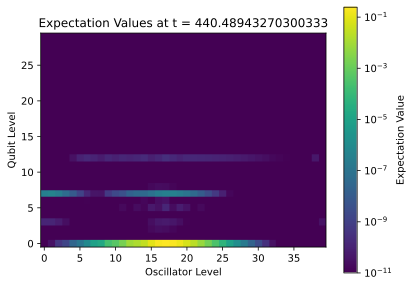

In [26]:
plot_heatmap(results[0], time_index=440, product_to_dressed = product_to_dressed, qubit_levels=qubit_level, oscillator_levels=osc_level)

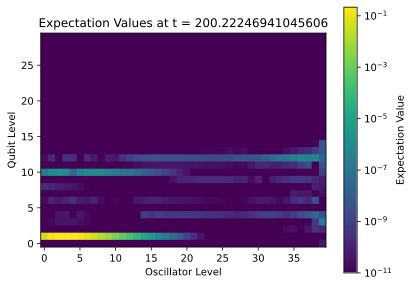

In [27]:
plot_heatmap(results[1], time_index=200, product_to_dressed = product_to_dressed, qubit_levels=qubit_level, oscillator_levels=osc_level)

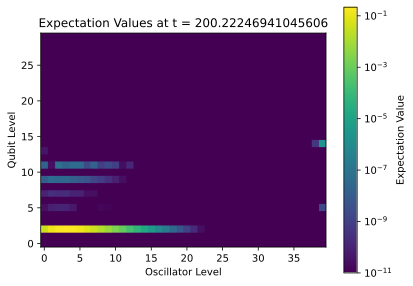

In [28]:
plot_heatmap(results[2], time_index=200, product_to_dressed = product_to_dressed, qubit_levels=qubit_level, oscillator_levels=osc_level)

(<Figure size 1000x500 with 3 Axes>, (<Axes3D: >, <Axes: >))

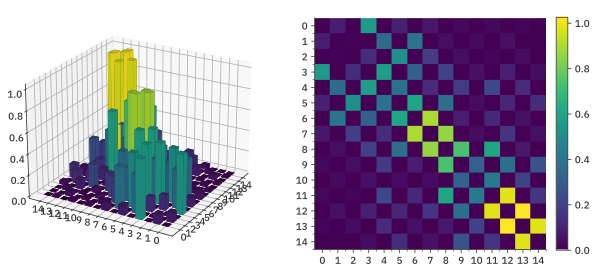

In [29]:
qbt.plot_matrixelements('n_operator',evals_count=15)

(<Figure size 1000x500 with 3 Axes>, (<Axes3D: >, <Axes: >))

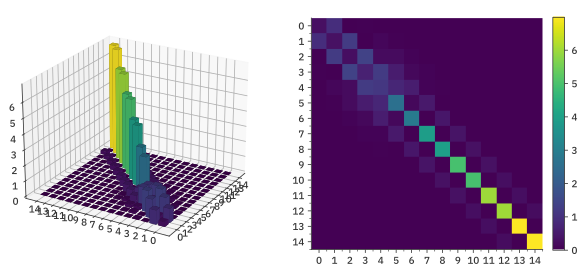

In [30]:
scqubits.Transmon(EJ=30,EC=1.2,ng=0.3,ncut=31).plot_matrixelements('n_operator',evals_count=15)